In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import crested
#import tangermeme
import keras
#from plotnine import *

%matplotlib inline
analysis_dir = "/staging/leuven/stg_00090/ASA/analysis/"
outdir = "/staging/leuven/stg_00090/ASA/analysis/Manuscript/Figures"

2026-03-04 13:12:35.628980: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 13:12:44.981474: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772626366.532887  111342 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772626367.135364  111342 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772626371.570869  111342 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
!nvidia-smi -L

GPU 0: NVIDIA A100-SXM4-80GB (UUID: GPU-1dca0dde-9349-655d-74e5-d8754a780704)


In [2]:
# Set the genome
genome = crested.Genome(
    "/staging/leuven/res_00001/genomes/homo_sapiens/CHM13v2_maskedY_rCRS/fasta/chm13v2.0_maskedY_rCRS.fa", 
    "/staging/leuven/res_00001/genomes/homo_sapiens/CHM13v2_maskedY_rCRS/fasta/chm13v2.0_maskedY_rCRS.chrom.sizes"
)

crested.register_genome(
    genome
)

2026-03-04T13:13:18.617842+0100 INFO Genome chm13v2.0_maskedY_rCRS registered.


# CC model

## Specific regions

### Predict for specific regions 

In [4]:
model_path = "/lustre1/project/stg_00090/ASA/analysis/analysis_Olga/3_T2T_analysis/2_CREsted_models/deepPeak/deepPeak_CC_mean_finetuned/checkpoints/02.keras"
model_cc = keras.models.load_model(model_path)
#adata_path = "/lustre1/project/stg_00090/ASA/analysis/analysis_Olga/3_T2T_analysis/2_CREsted_models/peak_regression/adata_cc_mean_norm.h5ad"
#adata_cc = ad.read_h5ad(adata_path)

# high Gini regions
adata_path = "/lustre1/project/stg_00090/ASA/analysis/analysis_Olga/3_T2T_analysis/2_CREsted_models/peak_regression/adata_cc_mean_norm_specific.h5ad"
adata_cc_specific = ad.read_h5ad(adata_path)

2026-03-02 14:22:56.805742: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-03-02 14:22:56.819091: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:167] env: CUDA_VISIBLE_DEVICES="0"
2026-03-02 14:22:56.819108: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2026-03-02 14:22:56.819115: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] retrieving CUDA diagnostic information for host: i28g30
2026-03-02 14:22:56.819399: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:190] hostname: i28g30
2026-03-02 14:22:56.827390: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:197] libcuda reported version is: 59

In [5]:
predictions_test = crested.tl.predict(
    adata_cc_specific,
    model_cc,
    genome=genome,
)

I0000 00:00:1772458077.491550 2909650 service.cc:152] XLA service 0x151878016ed0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772458077.503545 2909650 service.cc:160]   StreamExecutor device (0): Host, Default Version
2026-03-02 14:28:00.634673: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1772458089.263799 2909650 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


274805/274805 ━━━━━━━━━━━━━━━━━━━━ 7563s 27ms/step


In [7]:
# add predictions to adata
adata_cc_specific.layers["model_deepCC"] = predictions_test.T

In [ ]:
# Save the adata object with predictions
out_path = "/lustre1/project/stg_00090/ASA/analysis/analysis_Olga/3_T2T_analysis/2_CREsted_models/peak_regression/adata_cc_mean_norm_specific_with_predictions.h5ad"
adata_cc_specific.write_h5ad(out_path)

### Prediction heatmaps

In [ ]:
print(type(fig))
from crested.pl._utils import render_plot
import inspect
print(inspect.signature(render_plot))

2026-03-02T17:53:54.051712+0100 INFO Plotting heatmap correlations for split: test, models: ['model_deepCC']


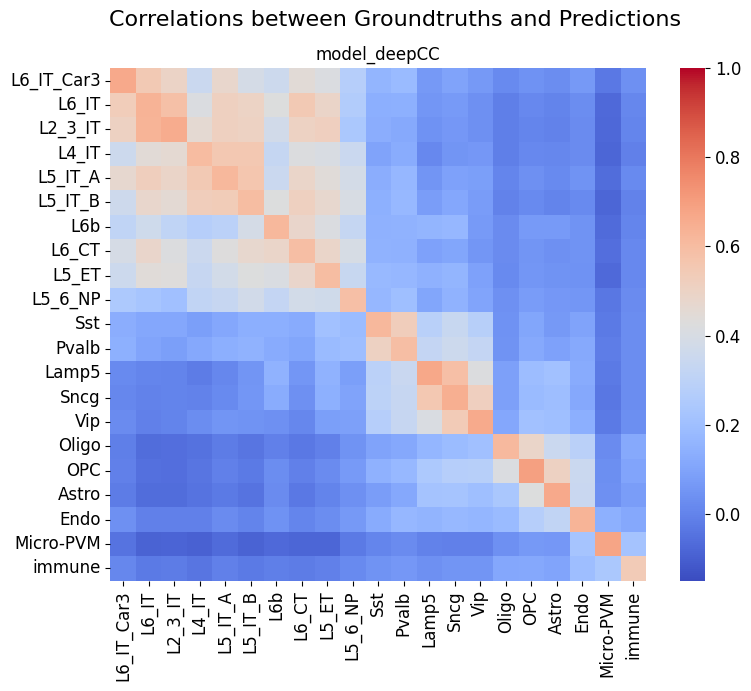

In [44]:
outpath = f"{outdir}/suppl/Suppl_for_Figure4_deepCC_groundtruth_predictions_specific.pdf"

crested.pl.heatmap.correlations_predictions(
    adata_cc_specific,
    reorder = True,
    split="test",
    title="Correlations between Groundtruths and Predictions",
    x_label_rotation=90,
    width=8,
    height=7,
    log_transform=True,
    vmax=1,
    vmin=-0.15,
    save_path = outpath
)


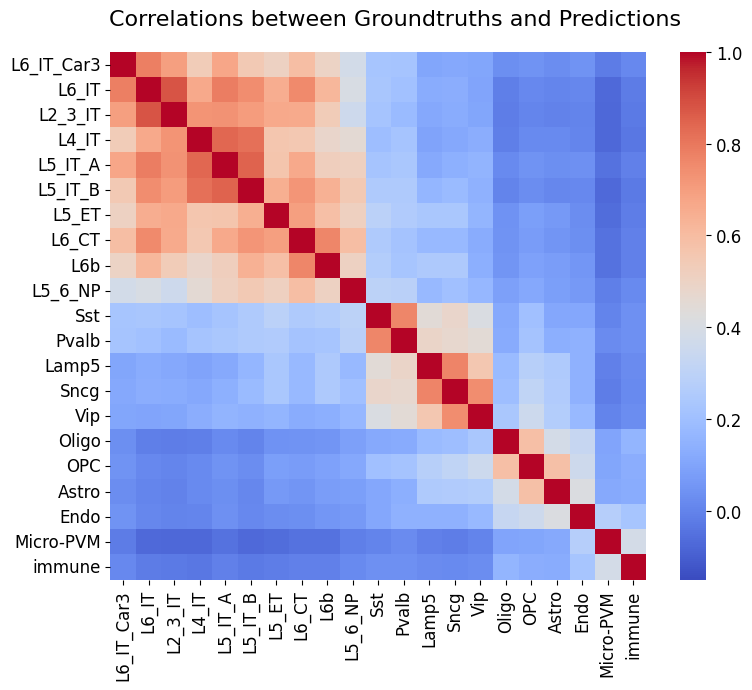

In [45]:
outpath = f"{outdir}/suppl/Suppl_for_Figure4_deepCC_self_corr_specific.pdf"

crested.pl.heatmap.correlations_self(
    adata_cc_specific,
    reorder = True,
    title="Correlations between Groundtruths and Predictions",
    x_label_rotation=90,
    width=8,
    height=7,
    log_transform=True,
    vmax=1,
    vmin=-0.15,
    save_path = outpath
)

### Prediction scatter plots

In [50]:
outpath = f"{outdir}/suppl/Suppl_for_Figure4_deepCC_target_vs_predictions_all_specific.pdf"

crested.pl.scatter.class_density(
    adata_cc_specific,
    split="test",
    log_transform=True,
    density_indication=False
    width=5,
    height=5,
    show = False
    #save_path = outpath
)

fig = plt.gcf()

for ax in fig.axes:
    for coll in ax.collections:   # scatter plots live here
        coll.set_sizes([2])       # smaller dots
        coll.set_rasterized(True) # rasterize points

fig.savefig(outpath, bbox_inches="tight")

2026-03-02T18:23:38.457952+0100 INFO Plotting density scatter for all targets and predictions, models: ['model_deepCC'], split: test


2026-03-02T17:19:41.440299+0100 INFO Plotting density scatter for class: L2_3_IT, models: ['model_deepCC'], split: test


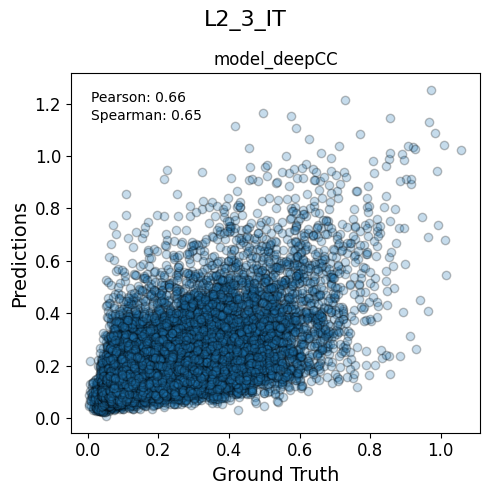

2026-03-02T17:19:41.675981+0100 INFO Plotting density scatter for class: Oligo, models: ['model_deepCC'], split: test


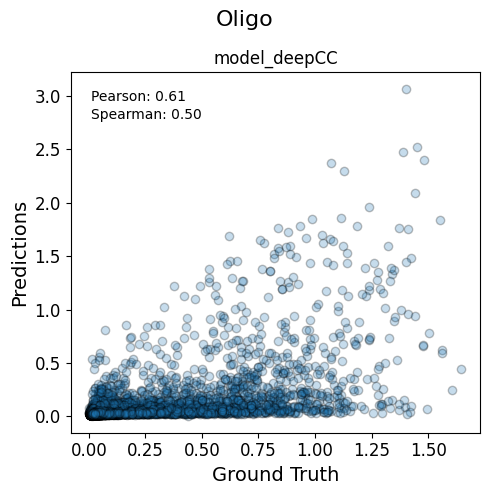

2026-03-02T17:19:41.905453+0100 INFO Plotting density scatter for class: Astro, models: ['model_deepCC'], split: test


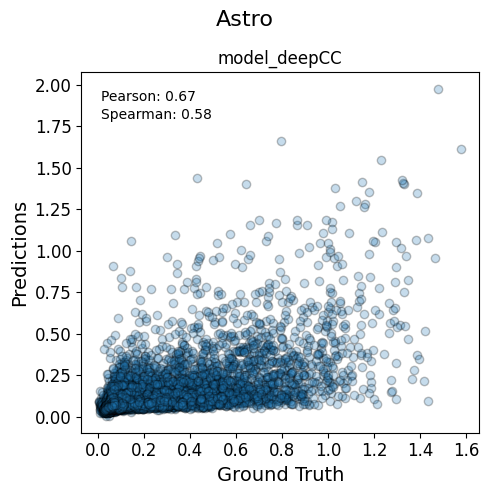

2026-03-02T17:19:42.151773+0100 INFO Plotting density scatter for class: Micro-PVM, models: ['model_deepCC'], split: test


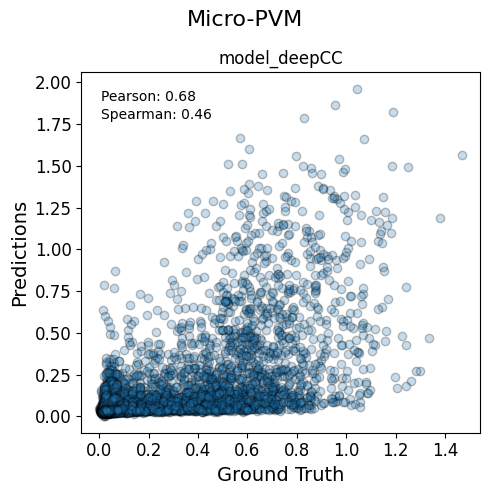

In [29]:
for ct in ["L2_3_IT", "Oligo", "Astro", "Micro-PVM"]:

    crested.pl.scatter.class_density(
        adata_cc_specific,
        class_name = ct,
        split="test",
        log_transform=True,
        width=5,
        height=5,
    )

## All regions

In [3]:
adata_path = "/lustre1/project/stg_00090/ASA/analysis/analysis_Olga/3_T2T_analysis/2_CREsted_models/peak_regression/adata_cc_mean_norm_with_predictions.h5ad"
adata_cc = ad.read_h5ad(adata_path)

2026-03-04T13:13:22.904276+0100 INFO Plotting heatmap correlations for split: test, models: ['deepCC']


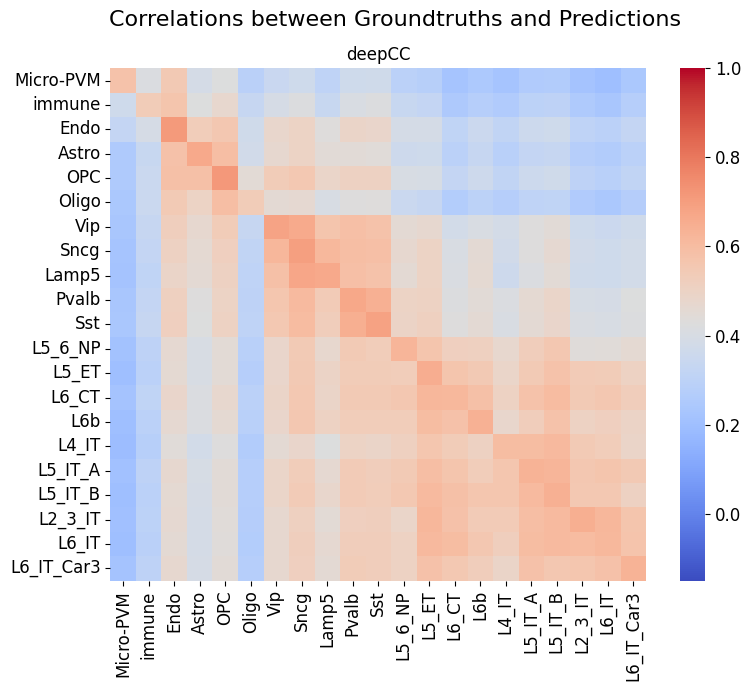

In [4]:
outpath = f"{outdir}/suppl/Suppl_for_Figure4_deepCC_groundtruth_predictions_full.pdf"

crested.pl.heatmap.correlations_predictions(
    adata_cc,
    reorder = True,
    split="test",
    title="Correlations between Groundtruths and Predictions",
    x_label_rotation=90,
    width=8,
    height=7,
    log_transform=True,
    vmax=1,
    vmin=-0.15,
    #save_path = outpath
)


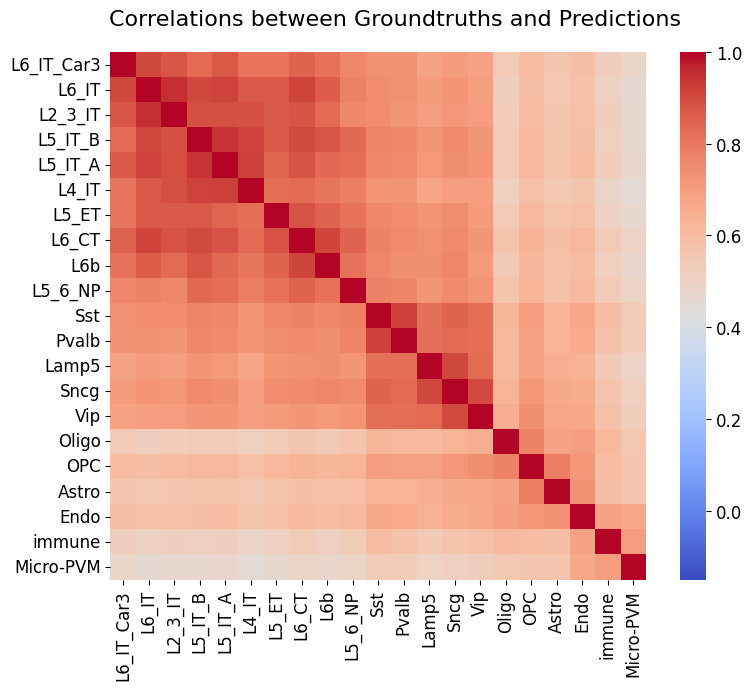

In [5]:
outpath = f"{outdir}/suppl/Suppl_for_Figure4_deepCC_self_corr_full.pdf"

crested.pl.heatmap.correlations_self(
    adata_cc,
    reorder = True,
    title="Correlations between Groundtruths and Predictions",
    x_label_rotation=90,
    width=8,
    height=7,
    log_transform=True,
    vmax=1,
    vmin=-0.15,
    #save_path = outpath
)

2026-03-04T13:23:03.178793+0100 INFO Plotting density scatter for all targets and predictions, models: ['deepCC'], split: test


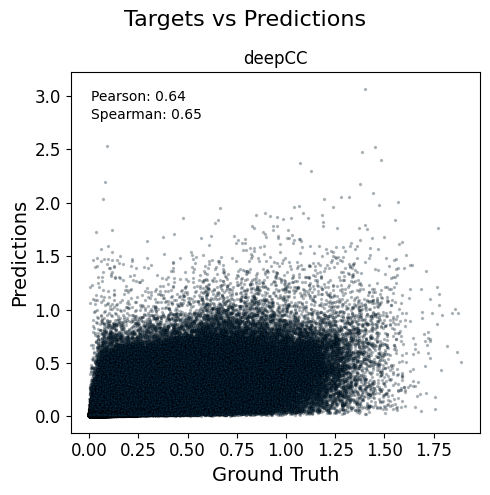

In [6]:
outpath = f"{outdir}/suppl/Suppl_for_Figure4_deepCC_target_vs_predictions_full_test.pdf"

crested.pl.scatter.class_density(
    adata_cc,
    split="test",
    log_transform=True,
    density_indication=False,
    width=5,
    height=5,
    show = False
    #save_path = outpath
)

fig = plt.gcf()

for ax in fig.axes:
    for coll in ax.collections:   # scatter plots live here
        coll.set_sizes([2])       # smaller dots
        coll.set_rasterized(True) # rasterize points

fig.savefig(outpath, bbox_inches="tight")
fig.show()

# SN model

## Specific regions

### Predict for specific regions

In [6]:
model_path = "/lustre1/project/stg_00090/ASA/analysis/analysis_Olga/3_T2T_analysis/2_CREsted_models/peak_regression/deepPeak_SN_mean_finetuned/01.keras"
model_sn = keras.models.load_model(model_path)

# high Gini regions
adata_path = "/lustre1/project/stg_00090/ASA/analysis/analysis_Olga/3_T2T_analysis/2_CREsted_models/peak_regression/adata_sn_mean_norm_specific.h5ad"
adata_sn_specific = ad.read_h5ad(adata_path)

I0000 00:00:1772554647.441216 1053281 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79192 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:c0:00.0, compute capability: 8.0


In [9]:
predictions_test = crested.tl.predict(
    adata_sn_specific,
    model_sn,
    genome=genome,
)

I0000 00:00:1772554887.452297 1055678 service.cc:152] XLA service 0x14a77800c400 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772554887.462908 1055678 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-80GB, Compute Capability 8.0
2026-03-03 17:21:28.769172: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1772554892.084977 1055678 cuda_dnn.cc:529] Loaded cuDNN version 90300


    54/194202 ━━━━━━━━━━━━━━━━━━━━ 6:11 2ms/step    

I0000 00:00:1772554907.726265 1055678 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


194202/194202 ━━━━━━━━━━━━━━━━━━━━ 320s 2ms/step


In [10]:
# add predictions to adata
adata_sn_specific.layers["model_deepSN"] = predictions_test.T

In [11]:
# Save the adata object with predictions
out_path = "/lustre1/project/stg_00090/ASA/analysis/analysis_Olga/3_T2T_analysis/2_CREsted_models/peak_regression/adata_sn_mean_norm_specific_with_predictions.h5ad"
adata_sn_specific.write_h5ad(out_path)

### Prediction heatmaps 

2026-03-03T17:38:19.574806+0100 INFO Plotting heatmap correlations for split: test, models: ['model_deepSN']


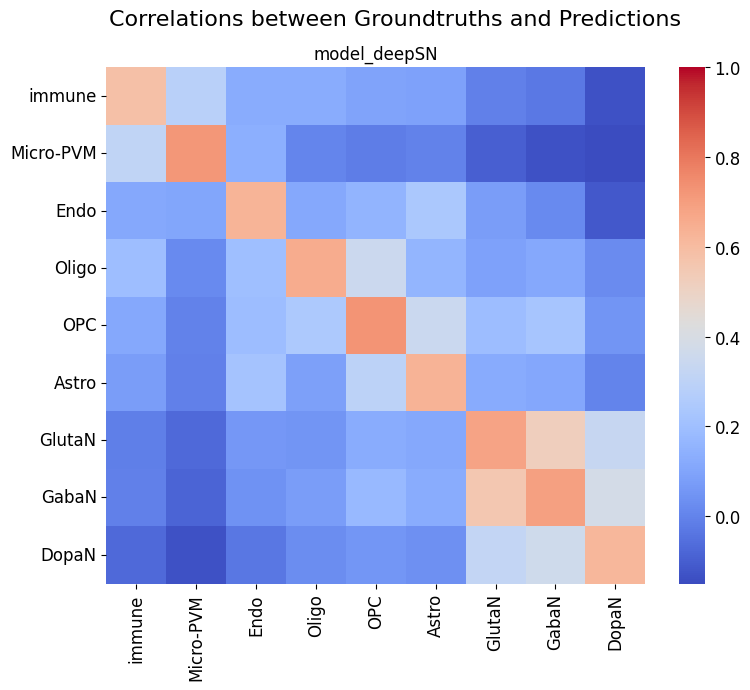

In [17]:
outpath = f"{outdir}/suppl/Suppl_for_Figure4_deepSN_groundtruth_predictions_specific.pdf"

crested.pl.heatmap.correlations_predictions(
    adata_sn_specific,
    reorder = True,
    split="test",
    title="Correlations between Groundtruths and Predictions",
    x_label_rotation=90,
    width=8,
    height=7,
    log_transform=True,
    vmax=1,
    vmin=-0.15,
    save_path = outpath
)


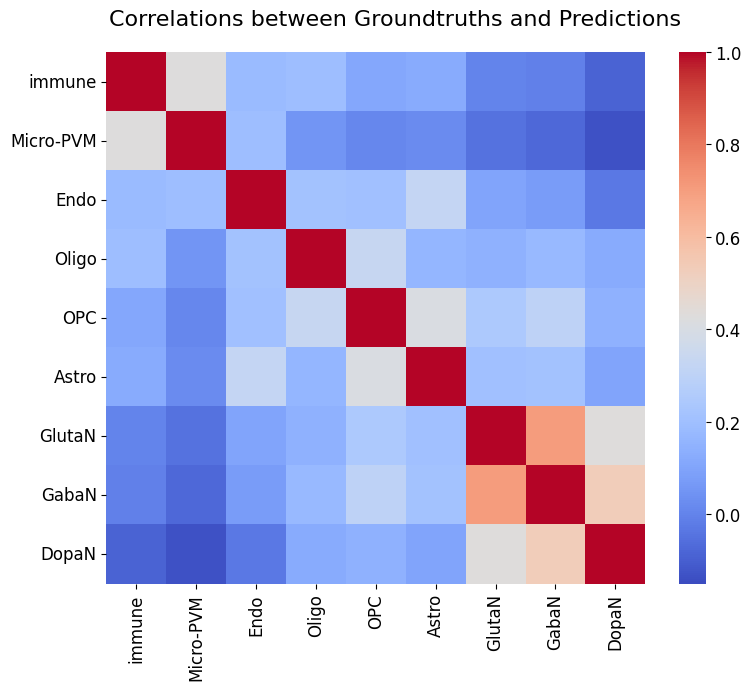

In [16]:
outpath = f"{outdir}/suppl/Suppl_for_Figure4_deepSN_self_corr_specific.pdf"

crested.pl.heatmap.correlations_self(
    adata_sn_specific,
    reorder = True,
    title="Correlations between Groundtruths and Predictions",
    x_label_rotation=90,
    width=8,
    height=7,
    log_transform=True,
    vmax=1,
    vmin=-0.15,
    save_path = outpath
)

### Prediction scatterplots

2026-03-03T17:43:12.629867+0100 INFO Plotting density scatter for all targets and predictions, models: ['model_deepSN'], split: test


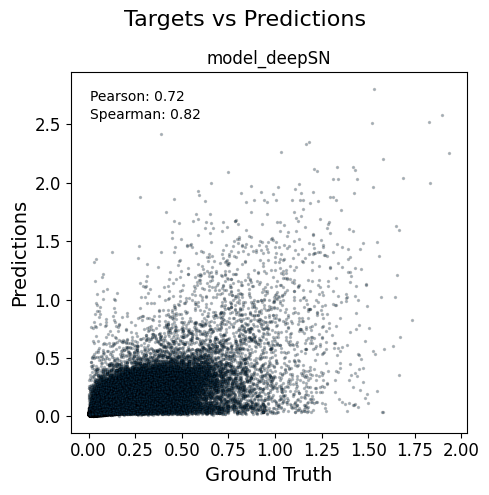

In [20]:
outpath = f"{outdir}/suppl/Suppl_for_Figure4_deepSN_target_vs_predictions_all_specific.pdf"

crested.pl.scatter.class_density(
    adata_sn_specific,
    split="test",
    log_transform=True,
    density_indication=False,
    width=5,
    height=5,
    show = False
    #save_path = outpath
)

fig = plt.gcf()

for ax in fig.axes:
    for coll in ax.collections:   # scatter plots live here
        coll.set_sizes([2])       # smaller dots
        coll.set_rasterized(True) # rasterize points

fig.savefig(outpath, bbox_inches="tight")
fig.show()

## Full dataset

In [22]:
adata_path = "/lustre1/project/stg_00090/ASA/analysis/analysis_Olga/3_T2T_analysis/2_CREsted_models/peak_regression/adata_sn_mean_norm_with_predictions.h5ad"
adata_sn = ad.read_h5ad(adata_path)

2026-03-03T16:52:54.996197+0100 INFO Plotting heatmap correlations for split: test, models: ['deepSN']


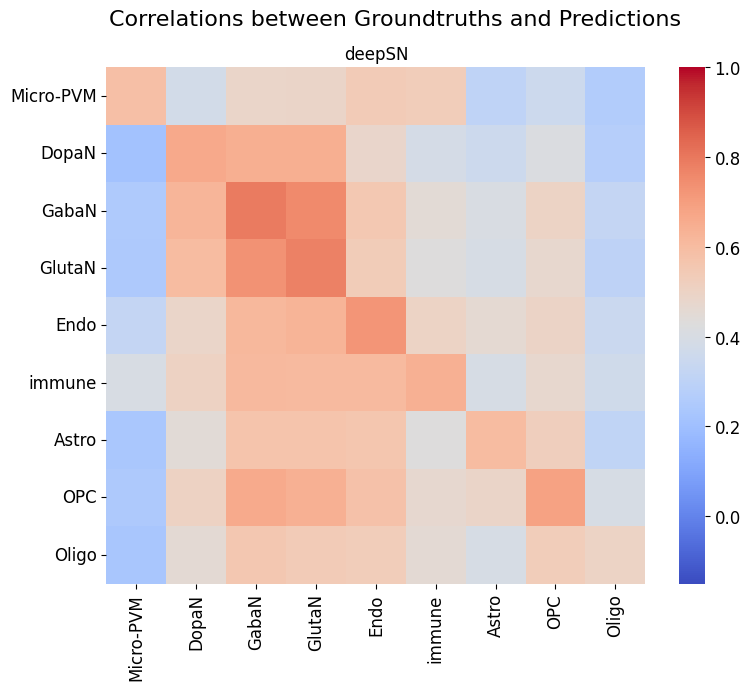

In [6]:
outpath = f"{outdir}/suppl/Suppl_for_Figure4_deepSN_groundtruth_predictions_specific.pdf"

crested.pl.heatmap.correlations_predictions(
    adata_sn,
    reorder = True,
    split="test",
    title="Correlations between Groundtruths and Predictions",
    x_label_rotation=90,
    width=8,
    height=7,
    log_transform=True,
    vmax=1,
    vmin=-0.15,
    #save_path = outpath
)


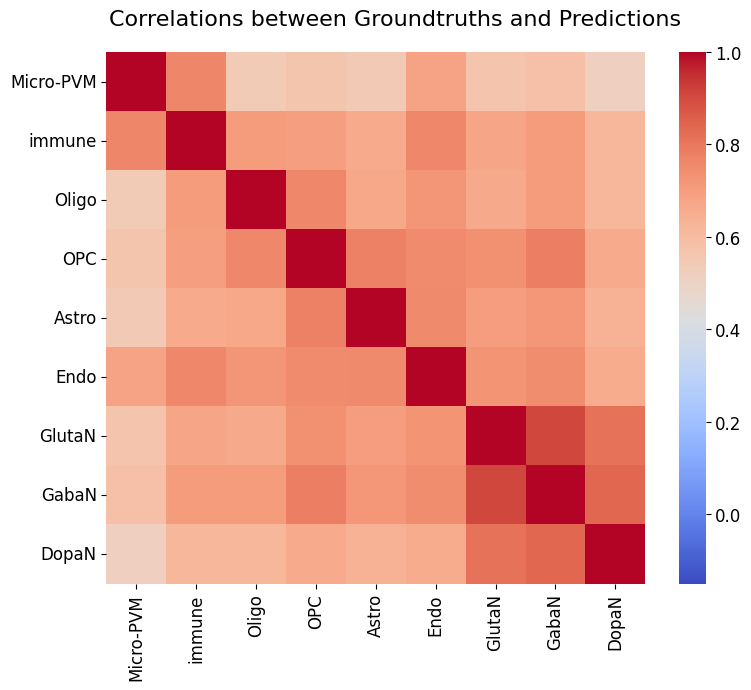

In [8]:
outpath = f"{outdir}/suppl/Suppl_for_Figure4_deepSN_self_corr_full.pdf"

crested.pl.heatmap.correlations_self(
    adata_sn,
    reorder = True,
    title="Correlations between Groundtruths and Predictions",
    x_label_rotation=90,
    width=8,
    height=7,
    log_transform=True,
    vmax=1,
    vmin=-0.15,
    #save_path = outpath
)

2026-03-03T18:05:12.047853+0100 INFO Plotting density scatter for all targets and predictions, models: ['deepSN'], split: test


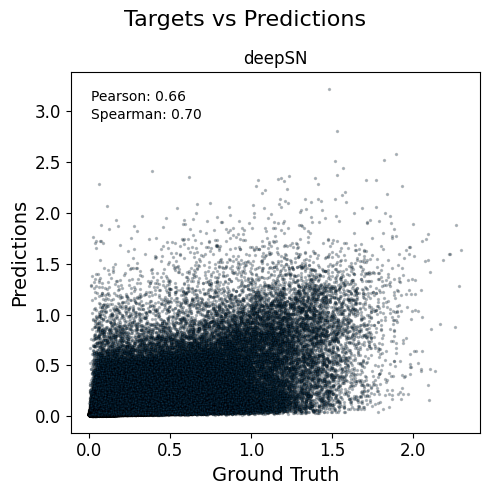

In [24]:
outpath = f"{outdir}/suppl/Suppl_for_Figure4_deepSN_target_vs_predictions_full_test.pdf"

crested.pl.scatter.class_density(
    adata_sn,
    split="test",
    log_transform=True,
    density_indication=False,
    width=5,
    height=5,
    show = False
    #save_path = outpath
)

fig = plt.gcf()

for ax in fig.axes:
    for coll in ax.collections:   # scatter plots live here
        coll.set_sizes([2])       # smaller dots
        coll.set_rasterized(True) # rasterize points

fig.savefig(outpath, bbox_inches="tight")
fig.show()

## BICCN enhancer predictions

In [11]:
#!wget --timestamping 'ftp://hgdownload.cse.ucsc.edu/goldenPath/mm10/bigZips/mm10.chrom.sizes' -O mm10.chrom.sizes 
!wget --timestamping 'ftp://hgdownload.cse.ucsc.edu/goldenPath/mm10/bigZips/mm10.fa.gz' -O mm10.fa.gz 

for details.

--2026-02-27 15:16:30--  ftp://hgdownload.cse.ucsc.edu/goldenPath/mm10/bigZips/mm10.fa.gz
           => ‘mm10.fa.gz’
Resolving hgdownload.cse.ucsc.edu (hgdownload.cse.ucsc.edu)... 128.114.119.163
Connecting to hgdownload.cse.ucsc.edu (hgdownload.cse.ucsc.edu)|128.114.119.163|:21... connected.
Logging in as anonymous ... Logged in!
==> SYST ... done.    ==> PWD ... done.
==> TYPE I ... done.  ==> CWD (1) /goldenPath/mm10/bigZips ... done.
==> SIZE mm10.fa.gz ... 870141360
==> PASV ... done.    ==> RETR mm10.fa.gz ... done.
Length: 870141360 (830M) (unauthoritative)

mm10.fa.gz          100%[===================>] 829.83M  16.6MB/s    in 51s     

2026-02-27 15:17:23 (16.4 MB/s) - ‘mm10.fa.gz’ saved [870141360]



In [14]:
genome_fasta = "mm10.fa"
genome_chrom_sizes  = "mm10.chrom.sizes" 
genome = crested.Genome(genome_fasta, genome_chrom_sizes)
crested.register_genome(genome)

2026-02-27T15:19:58.542932+0100 INFO Genome mm10 registered.


In [16]:
import polars as pl
enh_path = "biccn_enhancers.csv"
df = pl.read_csv(enh_path)
df.filter(pl.col("species") == "human")

old_idx,chrom,start,end,name,target_ct,second_target_ct,specificity,strength,enhancerID,species
i64,str,i64,i64,str,str,str,str,str,str,str
528,"""chr1""",15736003,15736289,"""chr1:15736003-15736289""","""Astro""",null,"""On-Target""","""weak""","""AiE0386h""","""human"""
531,"""chr1""",44592220,44592475,"""chr1:44592220-44592475""","""Oligo""",null,"""On-Target""","""strong""","""AiE0401h""","""human"""
536,"""chr1""",168424024,168424646,"""chr1:168424024-168424646""","""Sst""",null,"""On-Target""","""weak""","""AiE1008h""","""human"""
538,"""chr1""",219881964,219882430,"""chr1:219881964-219882430""","""Astro""",null,"""On-Target""","""strong""","""AiE0387h""","""human"""
543,"""chr11""",729566,729984,"""chr11:729566-729984""","""Oligo""","""OPC""","""On-Target""","""weak""","""AiE0391h""","""human"""
…,…,…,…,…,…,…,…,…,…,…
667,"""chr8""",56293639,56294037,"""chr8:56293639-56294037""","""Sst""","""SstChodl""","""On-Target""","""weak""","""AiE0529h""","""human"""
672,"""chr9""",81717533,81717734,"""chr9:81717533-81717734""","""Oligo""",null,"""On-Target""","""weak""","""AiE0410h""","""human"""
673,"""chr9""",123741899,123742461,"""chr9:123741899-123742461""","""Astro""",null,"""On-Target""","""weak""","""AiE0385h""","""human"""
